In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv('sleep.csv')

In [3]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea



Столбцы набора данных:  
- ID человека: идентификатор для каждого человека.  
- Пол: пол человека (мужчина/женщина).  
- Возраст: возраст человека в годах.  
- Род занятий: род занятий или профессия человека.  
- Продолжительность сна (часы): количество часов, которые человек спит в день.  
- Качество сна (шкала: 1-10): субъективная оценка качества сна в диапазоне от 1 до 10.  
- Уровень физической активности (минут/день): количество минут, в течение которых человек занимается физической активностью ежедневно.  
- Уровень стресса (шкала: 1-10): субъективная оценка уровня стресса, испытываемого человеком, в диапазоне от 1 до 10.  
- Категория ИМТ: категория индекса массы тела человека (например, недостаточный вес, нормальный вес, избыточный вес).  
- Артериальное давление (систолическое/диастолическое): измерение артериального давления человека, указанное как систолическое давление над диастолическим давлением.  
- Частота сердечных сокращений (уд/мин): частота сердечных сокращений человека в состоянии покоя в ударах в минуту.  
- Ежедневные шаги: количество шагов, которые человек делает за день.  
- Нарушение сна: наличие или отсутствие нарушения сна у человека (отсутствует, бессонница, апноэ во сне).  


### **Выделим и предобработаем целевую переменную: нарушение сна**

In [4]:
df['Sleep Disorder'].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

**Заменим nan на 'doesn't have'**

In [5]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna("doesn't have")
df['Sleep Disorder'].unique()

array(["doesn't have", 'Sleep Apnea', 'Insomnia'], dtype=object)

In [6]:
sleep_dic = {'Insomnia': 0, "doesn't have":1, 'Sleep Apnea':2}
df['Sleep Disorder'] = df['Sleep Disorder'].map(sleep_dic)

In [7]:
Y = df['Sleep Disorder']
df = df.drop('Sleep Disorder', axis=1)

### **Предобработаю данные**

**Удалю незначащую колокнку с айди и преобразую гендер к бинарному числовому, а не текстовому виду**

In [8]:
df = df.drop('Person ID', axis=1)

In [9]:
df['Gender'] = df['Gender'].map({"Male":0, "Female":1})

In [10]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200
1,0,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000
2,0,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000
3,0,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000
4,0,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000


**Разобью возраст на категории по 5 лет, тк идейно, что 23, что 24. Разницы большой нет (влияет не возраст в пределах 5 лет, а показатели организма)** 

In [11]:
print(df['Age'].min(), df['Age'].max())

27 59


In [12]:
groups = []
for i in range(df['Age'].min() - 1, df['Age'].max() + 5, 5):
    groups.append(i)
groups_cut = pd.cut(df['Age'].values, groups)
df['Age'] = groups_cut.codes

In [13]:
print(df['Age'].min(), df['Age'].max())

0 6


In [14]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,0,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200
1,0,0,Doctor,6.2,6,60,8,Normal,125/80,75,10000
2,0,0,Doctor,6.2,6,60,8,Normal,125/80,75,10000
3,0,0,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000
4,0,0,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000


In [15]:
df['Occupation'].unique()

array(['Software Engineer', 'Doctor', 'Sales Representative', 'Teacher',
       'Nurse', 'Engineer', 'Accountant', 'Scientist', 'Lawyer',
       'Salesperson', 'Manager'], dtype=object)

**Нельзя как-то эмпирически разделить эти профессии однозначно, поэтому воспользуюсь просто лейбл декодером**

In [16]:
le = LabelEncoder()
le.fit(df['Occupation'].unique())
le.classes_

array(['Accountant', 'Doctor', 'Engineer', 'Lawyer', 'Manager', 'Nurse',
       'Sales Representative', 'Salesperson', 'Scientist',
       'Software Engineer', 'Teacher'], dtype=object)

In [17]:
df['Occupation'] = le.transform(df['Occupation'])

In [18]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,0,9,6.1,6,42,6,Overweight,126/83,77,4200
1,0,0,1,6.2,6,60,8,Normal,125/80,75,10000
2,0,0,1,6.2,6,60,8,Normal,125/80,75,10000
3,0,0,6,5.9,4,30,8,Obese,140/90,85,3000
4,0,0,6,5.9,4,30,8,Obese,140/90,85,3000


**Разобьем сон на группы с ходом 0.5 (фазы сна)**

In [19]:
print(df['Sleep Duration'].min(), df['Sleep Duration'].max())

5.8 8.5


In [20]:
df['Sleep Duration'] = df['Sleep Duration'] * 10

In [21]:
groups = []
for i in range(54, 90, 5):
    groups.append(i)
groups_cut = pd.cut(df['Sleep Duration'].values, groups)
df['Sleep Duration'] = groups_cut.codes

In [22]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,0,9,1,6,42,6,Overweight,126/83,77,4200
1,0,0,1,1,6,60,8,Normal,125/80,75,10000
2,0,0,1,1,6,60,8,Normal,125/80,75,10000
3,0,0,6,0,4,30,8,Obese,140/90,85,3000
4,0,0,6,0,4,30,8,Obese,140/90,85,3000


**Закодирую Категория ИМТ**

In [23]:
le2 = LabelEncoder()
le2.fit(df['BMI Category'].unique())
df['BMI Category'] = le2.transform(df['BMI Category'])

In [24]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,0,0,9,1,6,42,6,3,126/83,77,4200
1,0,0,1,1,6,60,8,0,125/80,75,10000
2,0,0,1,1,6,60,8,0,125/80,75,10000
3,0,0,6,0,4,30,8,2,140/90,85,3000
4,0,0,6,0,4,30,8,2,140/90,85,3000


**Предобработаю давление**

In [25]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)

In [26]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Systolic,Diastolic
0,0,0,9,1,6,42,6,3,126/83,77,4200,126,83
1,0,0,1,1,6,60,8,0,125/80,75,10000,125,80
2,0,0,1,1,6,60,8,0,125/80,75,10000,125,80
3,0,0,6,0,4,30,8,2,140/90,85,3000,140,90
4,0,0,6,0,4,30,8,2,140/90,85,3000,140,90


In [27]:
df['Systolic'] = df['Systolic'].astype(int)
df['Diastolic'] = df['Diastolic'].astype(int)

In [28]:
def determine_pressure_status(row):
    systolic = row['Systolic']
    diastolic = row['Diastolic']
    if systolic < 90 or diastolic < 60:
        return -1  # Пониженное давление
    elif systolic > 120 or diastolic > 80:
        return 1   # Повышенное давление
    else:
        return 0   # Нормальное давление
df['PressureStatus'] = df.apply(determine_pressure_status, axis=1)

In [29]:
df = df.drop(['Blood Pressure', 'Systolic', 'Diastolic'], axis=1)


In [30]:
df['Daily Steps'].unique()

array([ 4200, 10000,  3000,  3500,  8000,  4000,  4100,  6800,  5000,
        7000,  5500,  5200,  5600,  3300,  4800,  7500,  7300,  6200,
        6000,  3700])

In [31]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,PressureStatus
0,0,0,9,1,6,42,6,3,77,4200,1
1,0,0,1,1,6,60,8,0,75,10000,1
2,0,0,1,1,6,60,8,0,75,10000,1
3,0,0,6,0,4,30,8,2,85,3000,1
4,0,0,6,0,4,30,8,2,85,3000,1


**Проверим на наличие пропусков в данных**

In [32]:
df.isna().sum()

Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
PressureStatus             0
dtype: int64

### Настроить и применить модули для решения задачи кластеризации Agglomerative Clustering и k-Means

In [33]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, random_state = 100)
km_predict = kmeans.fit_predict(df)

In [34]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters = 3)
ac_predict = ac.fit_predict(df)

### Используя изученные ранее метрики оценить качество модели кластеризации (внешние и внутренние)

In [35]:
from sklearn.metrics import davies_bouldin_score, silhouette_score, adjusted_rand_score

def print_metrics(km_predict, ac_predict):
    db_kmeans = davies_bouldin_score(df, km_predict)
    sil_kmeans = silhouette_score(df, km_predict)
    ari_kmeans = adjusted_rand_score(Y, km_predict)

    db_agglo = davies_bouldin_score(df, ac_predict)
    sil_agglo = silhouette_score(df, ac_predict)
    ari_agglo = adjusted_rand_score(Y, ac_predict)

    print(f'k-means коэф Дэвиса-Болдина = {db_kmeans}')
    print(f'agglomarative коэф Дэвиса-Болдина  = {db_agglo}')
    print()
    print(f'k-means силуэтный коэф = {sil_kmeans}')
    print(f'agglomarative коэф силуэтный коэф = {sil_agglo}')
    print()
    print(f'k-means индекс Рэнда = {ari_kmeans}')
    print(f'agglomarative индекс Рэнда = {ari_agglo}')

print_metrics(km_predict, ac_predict)

k-means коэф Дэвиса-Болдина = 0.6021270065373333
agglomarative коэф Дэвиса-Болдина  = 0.6042398010954104

k-means силуэтный коэф = 0.6394298202726039
agglomarative коэф силуэтный коэф = 0.6359395062679352

k-means индекс Рэнда = 0.07637720403334697
agglomarative индекс Рэнда = 0.06379026558803398


In [36]:
Y.value_counts()

Sleep Disorder
1    219
2     78
0     77
Name: count, dtype: int64

In [37]:
pd.DataFrame(km_predict).value_counts()


0
0    142
2    137
1     95
Name: count, dtype: int64

In [38]:
change_km = {1: 0, 2:2, 0:1}
km_predict = pd.Series(km_predict).map(change_km).to_numpy()

In [39]:
r = adjusted_rand_score(Y, km_predict)
print(r)

0.07637720403334697


In [40]:
pd.DataFrame(ac_predict).value_counts()

0
1    148
0    137
2     89
Name: count, dtype: int64

In [41]:
change_ag= {1: 1, 2:0, 0:2}
ag_predict = pd.Series(ac_predict).map(change_ag).to_numpy()

In [42]:
r = adjusted_rand_score(Y, ag_predict)
print(r)

0.06379026558803398


### Определить параметры, которые показывают лучшие результаты при проверке на данных с целевой переменной

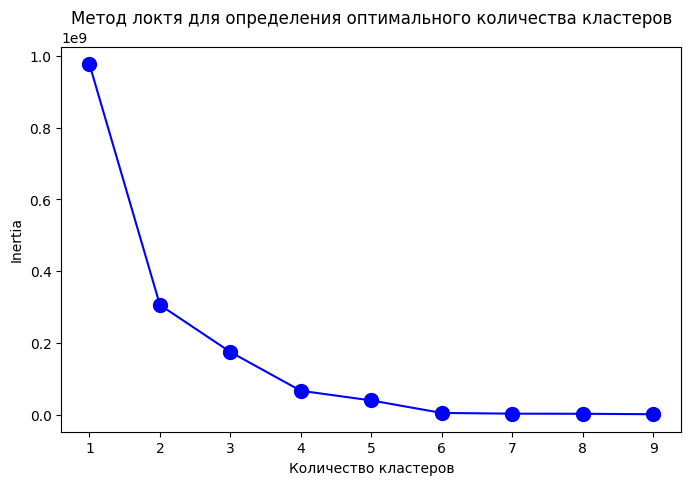

In [43]:
import matplotlib.pyplot as plt
inertia_values = []

# Вычисляем inertia для каждого количества кластеров. I
# Inertia в методе локтя — это сумма квадратов расстояний между объектами и их центроидом, то есть внутрикластерная дисперсия.  
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=100)
    kmeans.fit(df)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1,10) , inertia_values , 'bo-', markersize=10)
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя для определения оптимального количества кластеров')
plt.show()

Попробую на 2х и 4х кластерах, сравню с 3мя

In [44]:
results = {"Method": ["K-Means", "Agglomerative"]}

for n_clusters in [2, 3, 4, 6]:
    kmeans = KMeans(n_clusters=n_clusters, random_state=100, n_init=10)
    km_predict = kmeans.fit_predict(df)

    ac = AgglomerativeClustering(n_clusters=n_clusters)
    ac_predict = ac.fit_predict(df)

    results[f"DB_{n_clusters}"] = [
        davies_bouldin_score(df, km_predict),
        davies_bouldin_score(df, ac_predict),
    ]
    results[f"Silhouette_{n_clusters}"] = [
        silhouette_score(df, km_predict),
        silhouette_score(df, ac_predict),
    ]
    results[f"Rand_{n_clusters}"] = [
        adjusted_rand_score(Y, km_predict),
        adjusted_rand_score(Y, ac_predict),
    ]

df_results = pd.DataFrame(results)
df_results

,Method,DB_2,Silhouette_2,Rand_2,DB_3,Silhouette_3,Rand_3,DB_4,Silhouette_4,Rand_4,DB_6,Silhouette_6,Rand_6
0,K-Means,0.481552,0.646847,0.135204,0.384324,0.721057,0.191619,0.392073,0.741781,0.146302,0.173146,0.930229,0.245426
1,Agglomerative,0.595663,0.600720,0.008338,0.604240,0.635940,0.063790,0.396523,0.730098,0.118233,0.173146,0.930229,0.245426


In [45]:
kmeans = KMeans(n_clusters = 6, random_state = 100)
km_predict = kmeans.fit_predict(df)
ac = AgglomerativeClustering(n_clusters =6)
ac_predict = ac.fit_predict(df)
print('На 6 кластерах')
print_metrics(km_predict, ac_predict)

На 6 кластерах
k-means коэф Дэвиса-Болдина = 0.17278945465477383
agglomarative коэф Дэвиса-Болдина  = 0.17314612502644797

k-means силуэтный коэф = 0.9300635022796394
agglomarative коэф силуэтный коэф = 0.9302291153961271

k-means индекс Рэнда = 0.2502852894827887
agglomarative индекс Рэнда = 0.2454260569279619


In [46]:
from sklearn.decomposition import PCA
import seaborn as sns

def plot_clusters(df, labels, title):
    pca = PCA(n_components=2)  # Уменьшаем до 2D для визуализации
    reduced_data = pca.fit_transform(df)
    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=labels, palette="viridis", s=50, alpha=0.8)
    
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend(title="Cluster")
    plt.grid(True)
    plt.show()

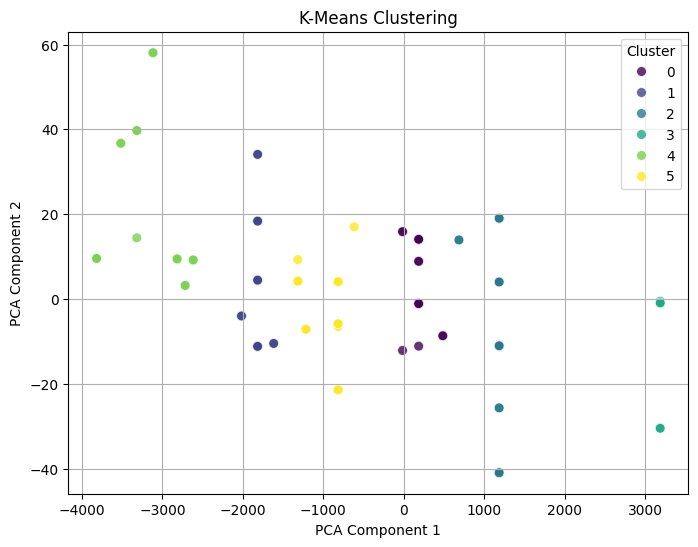

In [47]:
plot_clusters(df, km_predict, "K-Means Clustering")


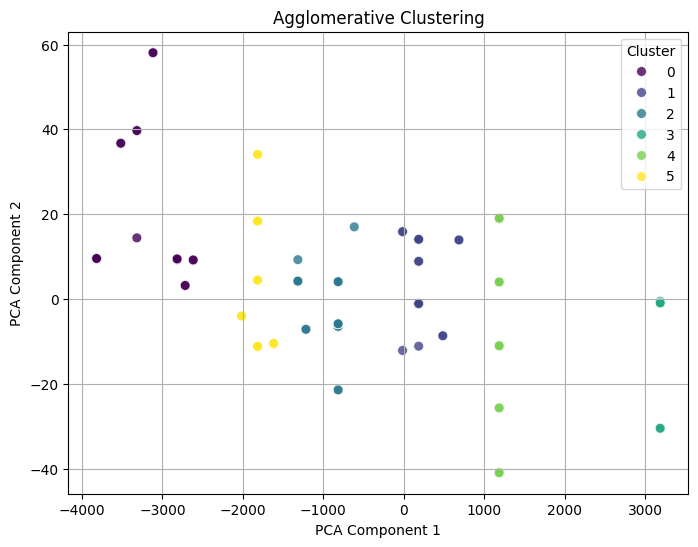

In [48]:
plot_clusters(df, ac_predict, "Agglomerative Clustering")

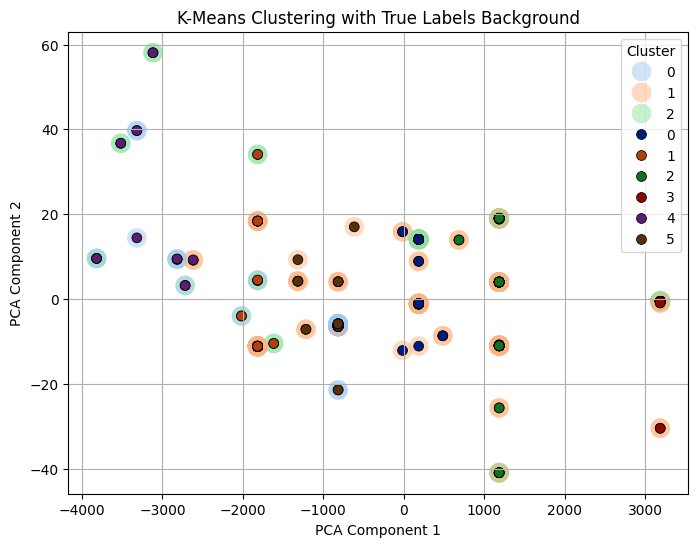

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

def plot_clusters(df, labels, true_labels, title):
    pca = PCA(n_components=2)  
    reduced_data = pca.fit_transform(df)

    plt.figure(figsize=(8, 6))

    # Отображаем фоновые кружки (истинные классы)
    sns.scatterplot(
        x=reduced_data[:, 0], 
        y=reduced_data[:, 1], 
        hue=true_labels, 
        palette="pastel", 
        s=200,  # Больший радиус для фона
        alpha=0.5, 
        edgecolor="none"
    )

    # Отображаем основные точки (предсказанные кластеры)
    sns.scatterplot(
        x=reduced_data[:, 0], 
        y=reduced_data[:, 1], 
        hue=labels, 
        palette="dark", 
        s=50,  # Меньший радиус для основной точки
        edgecolor="black"
    )

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend(title="Cluster")
    plt.grid(True)
    plt.show()

plot_clusters(df, km_predict, Y, "K-Means Clustering with True Labels Background")


## Реализовать алгоритм DBSCAN, сравнить результаты с другими алгоритмами кластеризации

In [90]:
from sklearn.cluster import DBSCAN
from sklearn.model_selection import ParameterGrid

cols_to_scale = ["Physical Activity Level", "Heart Rate", "Daily Steps", "Quality of Sleep", "Sleep Duration"]
df_scaled = df.copy()
df_scaled[cols_to_scale] = StandardScaler().fit_transform(df[cols_to_scale])
eps_values = np.arange(0.1, 1, 0.1)
min_samples_values = range(2, 10)
sil_scores = np.zeros((len(eps_values), len(min_samples_values)))
db_scores = np.zeros((len(eps_values), len(min_samples_values)))
n_clusters = np.zeros((len(eps_values), len(min_samples_values)))
best_params = None
best_sil_score = -1
for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(df_scaled[cols_to_scale])
        labels = db.labels_
        # Игнорируем случаи с одним кластером или только шумом
        if len(set(labels)) > 1:
            sil_scores[i,j] = silhouette_score(df_scaled[cols_to_scale], labels)
            db_scores[i,j] = davies_bouldin_score(df_scaled[cols_to_scale], labels)
            n_clusters[i,j] = len(set(labels)) - (1 if -1 in labels else 0)
            if sil_scores[i,j] > best_sil_score:
                best_sil_score = sil_scores[i,j] 
                best_params = {'eps': eps, 'min_samples': min_samples}
        else:
            sil_scores[i,j] = np.nan
            db_scores[i,j] = np.nan
            n_clusters[i,j] = np.nan


print(f"Лучшие параметры: {best_params}")
db = DBSCAN(**best_params).fit(df_scaled[cols_to_scale])
labels = db.labels_

print(f"Число кластеров: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Силуэтный коэффициент: {silhouette_score(df_scaled[cols_to_scale], labels)}")
print(f"Индекс Дэвиса-Болдина: {davies_bouldin_score(df_scaled[cols_to_scale], labels)}")

Лучшие параметры: {'eps': np.float64(0.30000000000000004), 'min_samples': 2}
Число кластеров: 39
Силуэтный коэффициент: 0.9678408749234392
Индекс Дэвиса-Болдина: 1.100393015981601


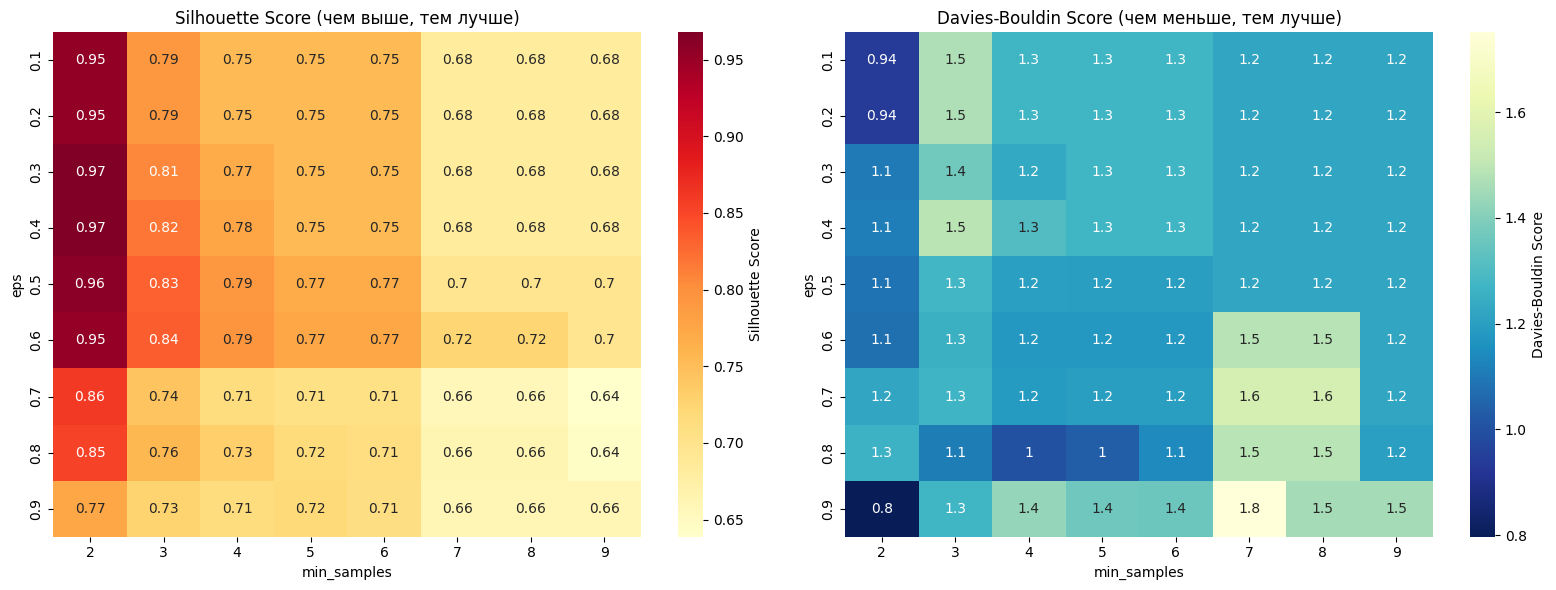

In [78]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График силуэтного коэффициента
sns.heatmap(
    sil_scores,
    xticklabels=min_samples_values,
    yticklabels=np.round(eps_values, 2),
    annot=True,
    cmap="YlOrRd",
    ax=ax1,
    cbar_kws={'label': 'Silhouette Score'}
)
ax1.set_xlabel("min_samples")
ax1.set_ylabel("eps")
ax1.set_title("Silhouette Score (чем выше, тем лучше)")

# График индекса Дэвиса-Болдина
sns.heatmap(
    db_scores,
    xticklabels=min_samples_values,
    yticklabels=np.round(eps_values, 2),
    annot=True,
    cmap="YlGnBu_r",  # Инвертируем цветовую схему (чем меньше, тем лучше)
    ax=ax2,
    cbar_kws={'label': 'Davies-Bouldin Score'}
)
ax2.set_xlabel("min_samples")
ax2.set_ylabel("eps")
ax2.set_title("Davies-Bouldin Score (чем меньше, тем лучше)")

plt.tight_layout()
plt.show()

## Реализовать конвейер на основе существующих методов предобработки

**Ранее было получено:**

На 6 кластерах

k-means коэф Дэвиса-Болдина = 0.17278945465477383

k-means силуэтный коэф = 0.9300635022796394


agglomarative коэф Дэвиса-Болдина  = 0.17314612502644797

agglomarative коэф силуэтный коэф = 0.9302291153961271

In [91]:
final_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('dbscan', DBSCAN(**best_params))
    ])
labels = final_pipeline.fit_predict(df)
print(f"Silhouette Score: {silhouette_score(df, labels):.3f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(df, labels):.3f}")

Silhouette Score: 0.900
Davies-Bouldin Score: 4.787


## Добавить в конвейер собственные функции предобработки.Реализовать конвейер на основе предобработки данных и алгоритмом кластеризации

In [96]:
cols_to_scale = ["Physical Activity Level", "Heart Rate", "Daily Steps", 
                "Quality of Sleep", "Sleep Duration"]
cols_to_drop = ["Gender"] 
cols_to_pass = [col for col in df.columns if col not in cols_to_scale + cols_to_drop]

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), cols_to_scale),
        ('passthrough', 'passthrough', cols_to_pass)
    ]
)

def find_best_dbscan_params(X, eps_range=(0.1, 1.0, 0.1), min_samples_range=range(2, 10)):
    best_params = None
    best_score = -1
    
    for eps in np.arange(*eps_range):
        for min_samples in min_samples_range:
            db = DBSCAN(eps=eps, min_samples=min_samples)
            pipeline = Pipeline([
                ('preprocessor', preprocessor),
                ('dbscan', db)
            ])
            
            labels = pipeline.fit_predict(X)
            
            if len(set(labels)) > 1:  # Если есть кластеры кроме шума
                score = silhouette_score(preprocessor.transform(X), labels)
                if score > best_score:
                    best_score = score
                    best_params = {'eps': eps, 'min_samples': min_samples}
    
    return best_params

best_params = find_best_dbscan_params(df)

In [97]:
# финальный пайплайн
final_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('dbscan', DBSCAN(**best_params))
    ])
    
labels = final_pipeline.fit_predict(df)
    

In [98]:
X_transformed = preprocessor.transform(df)
print(f"Silhouette Score: {silhouette_score(X_transformed, labels):.3f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(X_transformed, labels):.3f}")

Silhouette Score: 0.922
Davies-Bouldin Score: 0.839
